# **PMR3508 - Exercício Programa 02**: <br> **Redes Neurais e o Dataset MNIST**
---
---

## ✏️ **Cabeçalho**:


### **NUSP**: `13686970`
### **Hash**: `66`

---

## 📜 **Descrição:**

Neste exercício, você irá trabalhar com o **dataset MNIST**, um conjunto de dados com 70.000 imagens de dígitos escritos à mão. Seu objetivo será aplicar os conceitos de **Redes Neurais Artificiais (ANNs)** vistos na aula teórica. Este EP está dividido em tarefas, sua formatação não deve ser alterada, mas novas células de código ou texto podem ser criadas nos blocos de cada tarefa.

---

## ⚠️ **Instruções:**
- Complete todas as tarefas abaixo, respondendo às perguntas e escrevendo o código necessário.
- Comente seu código para facilitar a correção.
- Entregue o notebook no formato `.ipynb`.

---



## ✅ **Tarefas:**

1. **Probabilidades de dígitos no *dataset***       ⇒ `2 pontos`
2. **Análise Exploratória de Dados (EDA)**          ⇒ `2 pontos`
3. **Treinamento e teste de Modelos**               ⇒ `2 pontos`
4. **Comunicação de Resultados e Visualizações**    ⇒ `2 pontos`
5. **Publicação no *Kaggle* e Documentação**        ⇒ `2 pontos`

---

<br>
<center>
        <h1>
        <b>
        BOA SORTE !!!
        </b>
        </h1>
</center>
<br>

---
---

## ⏳ Loading dos Dados

In [ ]:
import pickle
import random
import numpy as np
import os
from os.path import join

# Configuração de seeds para replicabilidade
np.random.seed(42)  # Seed para NumPy
random.seed(42)     # Seed para o módulo random

input_path = '/kaggle/input/mnist-data'  # Obtém o diretório atual
images_filepath = join(input_path, 'MNIST-images.pkl')
labels_filepath = join(input_path, 'MNIST-labels.pkl')
validation_images_filepath = join(input_path, 'MNIST-validation-images.pkl')

with open(images_filepath, 'rb') as f:
    X_tot = pickle.load(f)

with open(labels_filepath, 'rb') as f:
    y_tot = pickle.load(f)

with open(validation_images_filepath, 'rb') as f:
    X_val = pickle.load(f)

In [ ]:
'''
TESTE DE CARREGAMENTO DO DATASET POR VISUALIZAÇÃO
Este bloco visualiza algumas imagens do dataset MNIST para verificar se o
carregamento foi realizado corretamente.
'''

%matplotlib inline
import random
import matplotlib.pyplot as plt

def show_images(images, title_texts):
    # Função para mostrar as imagens com seus respectivos títulos
    cols = 3  # Número de colunas na visualização
    rows = int(len(images) / cols) + 1  # Calcula o número de linhas
    plt.figure(figsize=(12, 12))  # Define o tamanho da figura
    index = 1
    for x in zip(images, title_texts):  # Itera sobre as imagens e títulos
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)  # Adiciona um subplot
        plt.axis('off')  # Desativa os eixos
        plt.imshow(image, cmap=plt.cm.gray)  # Mostra a imagem em escala de cinza
        if (title_text != ''):
            plt.title(title_text, fontsize=15)  # Define o título da imagem
        index += 1
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição de títulos
    plt.show()  # Exibe a figura com as imagens e títulos

images_2_show = []  # Lista para armazenar as imagens a serem mostradas
titles_2_show = []  # Lista para armazenar os títulos das imagens
# Seleciona aleatoriamente 9 imagens de treino
for i in range(0, 9):
    r = random.randint(1, 60000)
    images_2_show.append(X_tot[r])  # Adiciona a imagem selecionada à lista
    titles_2_show.append(f"Imagem [{str(r)}] = {str(y_tot[r])}")  # Adiciona o título correspondente

show_images(images_2_show, titles_2_show)  # Exibe as imagens selecionadas

# 0️⃣ Suas bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, \
classification_report, log_loss

# 1️⃣ Tarefa 01: Probabilidades 🎲

## 🧑🏻‍💻 Item a)

Descubra o número do Dataset associado ao seu Hash.


In [ ]:
show_images([X_tot[66]], [f"Imagem [{str(66)}] = {str(y_tot[66])}"])

## 🔦 Item b)

Determine, para a imagem vinculada ao seu Hash, qual é a Probabilidade de um píxel claro (128 - 225) para esta única imagem?

In [ ]:
claro = 0
total = X_tot[66].size
for pixel in X_tot[66].flatten():
    if pixel >= 128:
        claro += 1

print(f'Probabilidade de um píxel claro na imagem do hash: {claro/total*100:.2f}%')

## ♟️ Item c)

Qual é a probabilidade de um píxel ser claro dentre todos os píxeis que tem a mesma classe que a sua imagem obtida em a)?

In [ ]:
cond = y_tot == 3
X_classe_3 = X_tot[cond]
claro = 0
soma = 0
total = len(X_classe_3)*X_classe_3[0].size
for image in X_classe_3.flatten():
    for pixel in image.flatten():
      if pixel >= 128:
          claro += 1

print(f'Probabilidade de um píxel claro dado que a imagem é um 3: {claro/total*100:.2f}%')

---

# 2️⃣ Tarefa 02: Análise Exploratória de Dados 📊

## ✨ Item a)

Conte quantas vezes cada dígito (de 0 a 9) aparece e responda:

1. Todos os dígitos aparecem a mesma quantidade?

2. Qual o valor médio dos píxeis de cada dígito?

In [ ]:
digits, frequency = np.unique(y_tot, return_counts=True)
digit_dict = {}
for digit, freq in zip(digits, frequency):
    print(f'Dígito {digit}: {freq} vezes')
    digit_dict[digit] = X_tot[y_tot == digit]

In [ ]:
sns.countplot(x=y_tot)
plt.xlabel('Dígito')
plt.ylabel('Frequência')
plt.title('Distribuição dos dígitos no conjunto de dados')
plt.show()

Os dígitos estão todos bem representados na base de dados, existem ligeiramente mais imagens rotuladas como 1.

In [ ]:
for digit in digit_dict.keys():
    media = 0
    for image in digit_dict[digit]:
        media += np.mean(image)
    print(f'Média dos píxeis do dígito {digit}: {media/len(digit_dict[digit]):.2f}')

Alguns dígitos necessitam de mais pixels para serem desenhados e elevam a média dos pixels nas imagens da classe.

## 📏 Item b)

Faça um histograma que mostre a distribuição dos valores dos píxeis para cada dígito. Há muitos valores que são “apagados” (ou seja, com valor 0) ou a distribuição dos valores é mais equilibrada entre os dígitos?


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for digit in digit_dict.keys():
    digit_pixels = digit_dict[digit].flatten()
    sns.histplot(digit_pixels, kde=True, ax = axes[digit//5, digit%5])
    axes[digit//5, digit%5].set_title(f"Distribuição dos pixels para o dígito {digit}", fontsize=9)

## 🤓 Item c)

Crie uma imagem para cada dígito (de 0 a 9) em que cada píxel dessa nova imagem representa a média do valor dos píxeis para aquela classe. Você consegue reconhecer os dígitos nas imagens criadas?

In [ ]:
img2show = []
titl2show = []
for digit in digit_dict.keys():
  imagem_media = np.empty((28, 28))
  for image in digit_dict[digit]:
    imagem_media  += image
  imagem_media /= len(digit_dict[digit])
  img2show.append(imagem_media)
  titl2show.append(f'Média dos pixels para o dígito {digit}')
show_images(img2show, titl2show)

Os números ainda são facilmente reconhecíveis.

---

# 3️⃣ Tarefa 03: Treinamento e Teste de Modelos 🤖

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_tot.reshape(X_tot.shape[0], -1), y_tot, test_size=0.2, random_state=42)

## 📈 Item a)

Treine a ANN1 com 784 entradas, 8 neurônios na 1⁠ª camada oculta, 8 neurônios na 2⁠ª camada oculta e 10 saídas. Utilize 5 épocas para o treinamento. Use a biblioteca `scikit-learn`:

- Input Layer: 784 entradas (28x28);
- Hidden Layer 1: 8 neurônios;
- Hidden Layer 2: 8 neurônios;
- Output Layer: 10 saídas; (Classificador 0-9)
- Treine com 10 épocas.

In [ ]:
model1 = MLPClassifier(hidden_layer_sizes=(8, 8), max_iter=5, random_state=42)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
print(f"Acurácia na base de teste: {accuracy_score(y_test, pred1)}")

## 📉 Item b)

Treine a ANN2 com 784 entradas, 256 neurônios na 1⁠ª camada oculta, 256 neurônios na 2⁠ª camada oculta, 256 neurônios na 3ª camada oculta, 256 neurônios na 4ª camada oculta e 10 saídas. Utilize 20 épocas dessa vez. Use a biblioteca `scikit-learn`.

- Input Layer: 784 entradas (28x28);
- Hidden Layer 1: 256 neurônios;
- Hidden Layer 2: 256 neurônios;
- Hidden Layer 3: 256 neurônios;
- Hidden Layer 4: 256 neurônios;
- Output Layer: 10 saídas; (Classificação 0-9)
- Treine com 20 épocas.

In [ ]:
model2 = MLPClassifier(hidden_layer_sizes=(256, 256, 256, 256), max_iter=20)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print(f"Acurácia na base de teste: {accuracy_score(y_test, pred2)}")

## ⚙️ Item c)

Agora você treinará um novo modelo, mais adequado. Para isso, gere ao menos 5 configurações de redes neurais, variando o número de camadas ocultas, o número de neurônios e o número de épocas. As configurações devem estar intermediárias entre `[8, 8]` e `[256, 256, 256, 256]`.

Utilize a função `GridSearchCV` para realizar uma busca exaustiva pelos hiperparâmetros e encontre a configuração que oferece o melhor classificador, justificando sua escolha com base nas métricas de validação.

In [ ]:
model = MLPClassifier(random_state=42)

param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128), (256, 128, 64), (256, 256, 128, 64)],
    'max_iter': [20, 100],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Melhores parâmetros encontrados:", grid_search.best_params_)
print("Melhor precisão obtida:", grid_search.best_score_)
hidden_layer_sizes = grid_search.best_params_['hidden_layer_sizes']
max_iter = grid_search.best_params_['max_iter']
best_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=42)
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

## 🔧 Item d)

Para os modelos treinados nas questões a) e b), além do classificador encontrado na questão c), compare o desempenho dos modelos, analisando se apresentam *underfitting* ou *overfitting*. Justifique com gráficos e análises.


In [ ]:
"""
def plot_learning_curve(estimator, X, y, title) -> None:
"""
"""
    Plota a curva de aprendizado para um modelo estimador, mostrando o desempenho em termos de acurácia 
    no conjunto de treino e de teste conforme o tamanho do conjunto de treinamento aumenta.

    Parâmetros:
    ----------
    estimator : object
        O modelo estimador (como uma instância de uma classe de modelo do scikit-learn) que será avaliado.
        O modelo deve implementar os métodos `fit` e `predict`.

    X : array-like, shape (n_samples, n_features)
        Dados de entrada para o treinamento, onde `n_samples` é o número de amostras e `n_features` é o 
        número de características.

    y : array-like, shape (n_samples,)
        Rótulos de saída correspondentes aos dados de entrada `X`.

    title : str
        Título do gráfico a ser exibido no topo da curva de aprendizado.

    Retorno:
    -------
    None
        A função não retorna nenhum valor. Exibe um gráfico da curva de aprendizado que compara a acurácia 
        nos conjuntos de treino e de teste em relação ao tamanho do conjunto de treinamento.

    Notas:
    -----
    Essa função utiliza a função `learning_curve` do scikit-learn para calcular a acurácia média nos 
    conjuntos de treino e teste em diferentes tamanhos de conjunto de treinamento. O gráfico gerado permite 
    uma análise visual de como o modelo generaliza com diferentes quantidades de dados de treinamento, 
    auxiliando na identificação de problemas de overfitting ou underfitting.

    Exemplo de Uso:
    --------------
    plot_learning_curve(estimator=MLPClassifier(), X=X_train, y=y_train, title="Curva de Aprendizado - MLPClassifier")
"""
"""
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5, scoring='accuracy')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label="Acurácia no Treino", marker='o')
    plt.plot(train_sizes, test_scores_mean, label="Acurácia no Teste", marker='o')
    plt.title(title)
    plt.xlabel("Tamanho do Conjunto de Treinamento")
    plt.ylabel("Acurácia")
    plt.legend(loc="best")
    plt.show()
    
plot_learning_curve(best_model, X_train, y_train, "Curva de Aprendizado - modelo encontrado")
""";

(anexei as imagens das curvas de aprendizado para um menor tempo de execução)
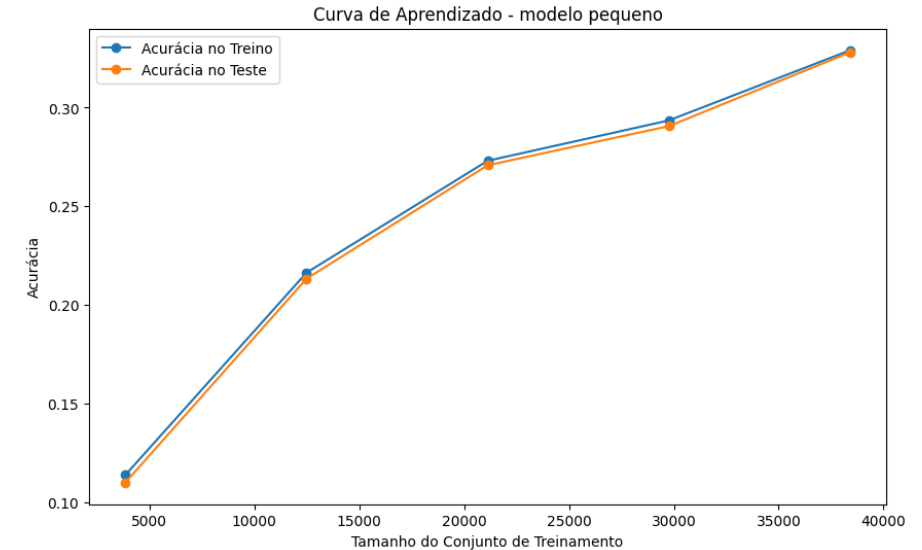
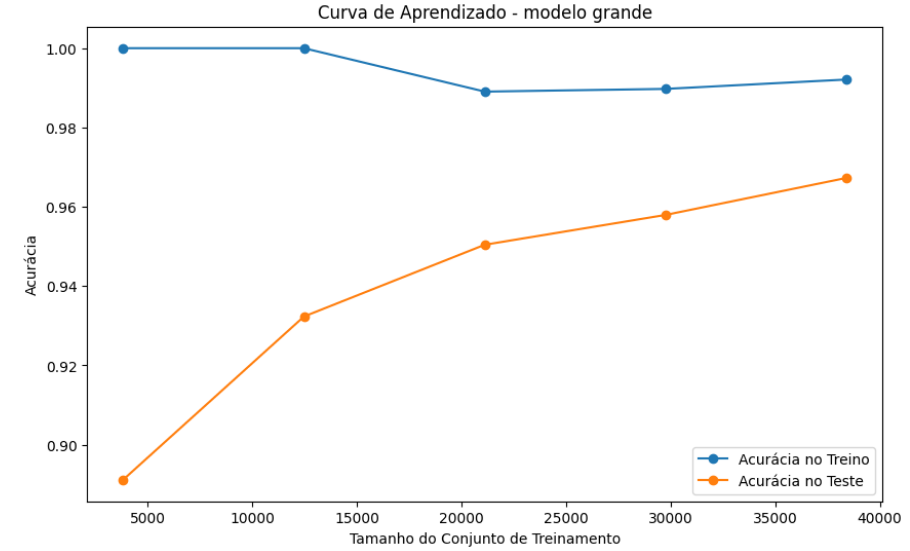
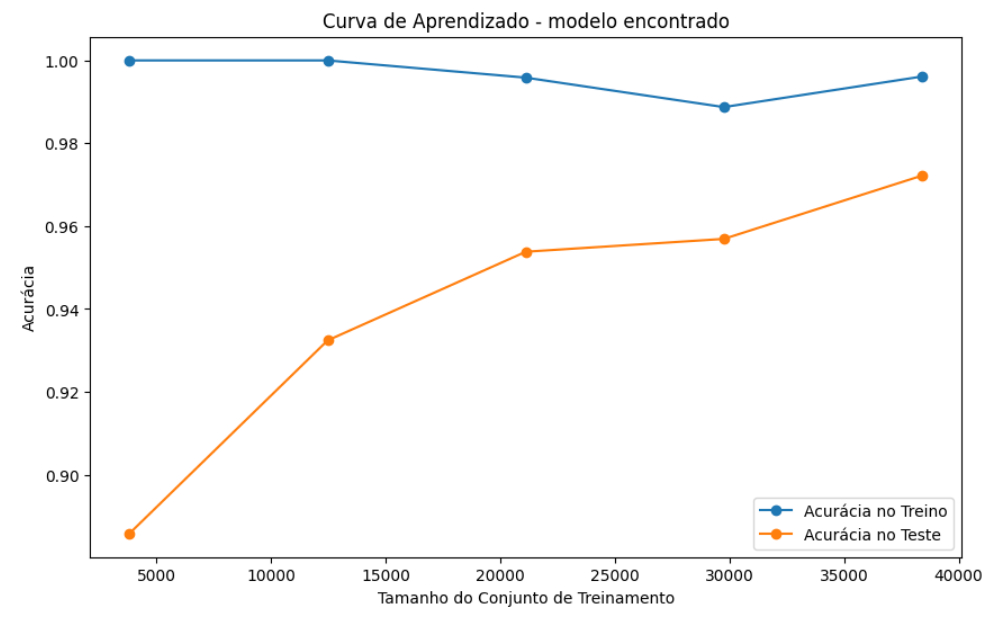

* O modelo inicial apresenta sinais de underfitting, não alcançando uma acurácia alta nas bases de treino ou de teste, o paralelismo entre as duas curvas indica que o modelo é demasiadamente simplístico.
* O modelo grande possui uma alta acurácia nos dois conjuntos, vemos que sua complexidade é mais adequada neste problema de classificação, porém embora as métricas se aproximem à medida que a base de dados cresce, a performance na base de treino ainda é significativamente maior e é possível que o modelo sofra de overfitting.
* O modelo encontrado na busca de parâmetros apresenta comportamento similar ao anterior e os mesmos comentários podem ser feitos.

---

# 4️⃣ Tarefa 04: Resultados e Visualizações 🤞🏻

## 🐳 Item a)

Gere e apresente uma matriz de confusão que mostre a distribuição das previsões do melhor modelo. Quais as métricas de Acurácia, Precisão, Recall e F1-Score para esse modelo?

In [ ]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.show()
print(f"acurácia: {accuracy_score(y_test, pred)}")
print(f"precisão: {precision_score(y_test, pred, average='macro')}")
print(f"recall: {recall_score(y_test, pred,average='macro')}")
print(f"F1-score: {f1_score(y_test, pred,average='macro')}")

## 🐸 Item b)

Exiba gráficos que mostram a evolução da acurácia e da perda (`Loss`) durante o treinamento do melhor modelo encontrado no item 3c).

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(best_model.loss_curve_, label='Loss')
plt.plot(1 - np.array(best_model.loss_curve_), label='Acurácia')
plt.title('Evolução da Perda e Acurácia durante o Treinamento')
plt.xlabel('Épocas')
plt.legend()
plt.grid()
plt.show()

As curvas se estabilizam rapidamente, a acurácia cresce rapidamente enquanto a perda decai, ficando muito próximas de 1 e 0, repectivamente, após 10 épocas indicando uma boa performance no treinamento. Quando o modelo ultrapassa 20 epócas a taxa de variação diminui e não há grande incentivo em continuar aumentando a quantidade de epócas.

## 🦖 Item c)

Escolha algumas imagens do conjunto de teste e mostre previsões do seu modelo, com acertos e erros. Discuta quais fatores podem ter contribuído para essas previsões corretas e incorretas.

In [ ]:
np.random.seed(10)

# Comparando as predições com os rótulos reais
correct_indices = np.where(pred == y_test)[0]
incorrect_indices = np.where(pred != y_test)[0]

random_correct_indices = np.random.choice(correct_indices, 9, replace=False)
random_incorrect_indices = np.random.choice(incorrect_indices, 9, replace=False)

correct_images = X_test[random_correct_indices]
correct_labels = y_test[random_correct_indices]
correct_predictions = pred[random_correct_indices]

incorrect_images = X_test[random_incorrect_indices]
incorrect_labels = y_test[random_incorrect_indices]
incorrect_predictions = pred[random_incorrect_indices]

correct_images = correct_images.reshape(-1, 28, 28)
incorrect_images = incorrect_images.reshape(-1, 28, 28)

titl2show_correct = [ f"Verdadeiro: {true}, Previsto: {pred}" for true, pred in zip(correct_labels, correct_predictions)]
titl2show_incorrect = [f"Verdadeiro: {true}, Previsto: {pred}" for true, pred in zip(incorrect_labels, incorrect_predictions)]
print("\033[0;32m Acertos")
show_images(correct_images, titl2show_correct)
print()
print("\033[0;31m Erros\n")
show_images(incorrect_images, titl2show_incorrect)

As previsões corretas aparentam ser imagens onde as formas dos dígitos estão bem definidas, espera-se que o classificador consiga distinguir esses números facilmente, para o olho humano os traços não são ambíguos.
Os erros do classificador aparentam acontecer em situações mais extremas, traços grotescos que podem ser propositalmente exagerados para que a forma de um dígito se pareça com outro.

---

In [ ]:
best_model.fit(X_tot.reshape(X_tot.shape[0], -1), y_tot)
final_pred = best_model.predict(X_val.reshape(X_val.shape[0], -1))

In [ ]:
import pandas as pd
ID = np.arange(1,len(final_pred) + 1)
df_previsao = pd.DataFrame()
df_previsao["ID"] = ID
df_previsao["Answer"] = final_pred
df_previsao.set_index("ID", inplace=True)
df_previsao.to_csv('/kaggle/working/PMR3058-2024-66-MNIST.csv', index = True)
df_previsao.head()